# Introduction
In this project I’m trying to predict how long a taxi trip will take using the NYC Taxi Trip Duration dataset. Trip duration affects scheduling, dispatching, and customer satisfaction, so having a good model helps reduce delays and makes planning easier. The dataset includes pickup time, passenger count, and pickup/dropoff coordinates, which let me create useful features like hour of day, day of week, and distance.

This notebook includes all work from Milestones 1–3 plus the new additions required for the final project. I clearly mark everything added after Milestone 3.

---------------------------------------
MILESTONE 1 — EXPLORATORY DATA ANALYSIS
---------------------------------------

## 1.1 Load Libraries and Dataset

In [1]:
# Importing the libraries I need for the project.
# I found this styling online and thought it looked nice, so I'm using it here.
# It just makes the plots look cleaner and easier to read.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_theme()

# Reading in the dataset from a local CSV file.
df = pd.read_csv("NYC.csv")
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## 1.2 Datetime Conversion + Feature Creation

In [2]:
# Converting the pickup time so I can extract useful parts from it.
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Creating extra features from the datetime column.
# These help capture traffic patterns and time-based behavior.
df['day_of_week'] = df['pickup_datetime'].dt.day_name()
df['hour'] = df['pickup_datetime'].dt.hour
df['month'] = df['pickup_datetime'].dt.month

# Removing extreme outliers and negative durations.
# Some trips were unrealistically long, so filtering makes the graphs readable.
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 7200)]

## 1.3 Distance Calculation (Haversine)

In [3]:
# I found this Haversine formula online and thought it would be neat to include.
# It calculates the distance between two coordinates, which is obviously important
# for understanding why some trips take longer than others.

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Applying the Haversine formula to the dataset.
df['distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

## 1.4 EDA Visuals

### Trip Duration Distribution

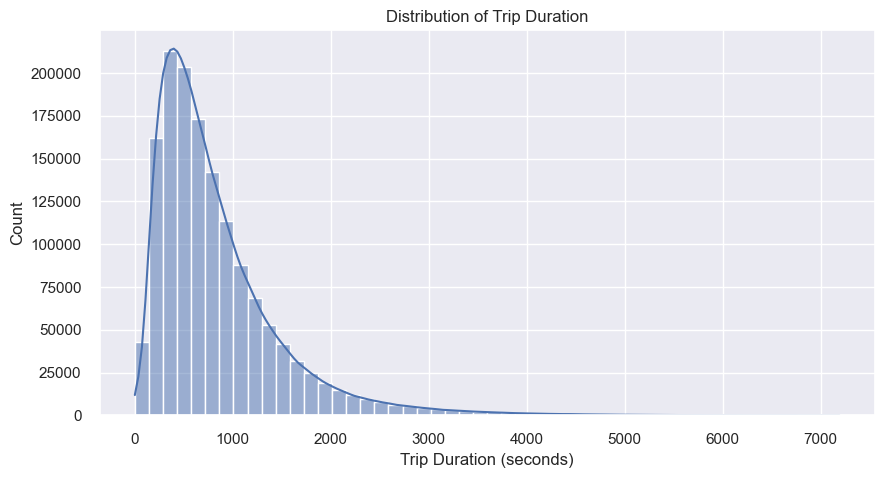

In [4]:
# Plotting the distribution of trip duration.
# This helps me see how skewed the data is and whether outliers are an issue.

plt.figure(figsize=(10,5))
sns.histplot(df['trip_duration'], kde=True, bins=50)
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.show()

### Trip Duration by Day of Week

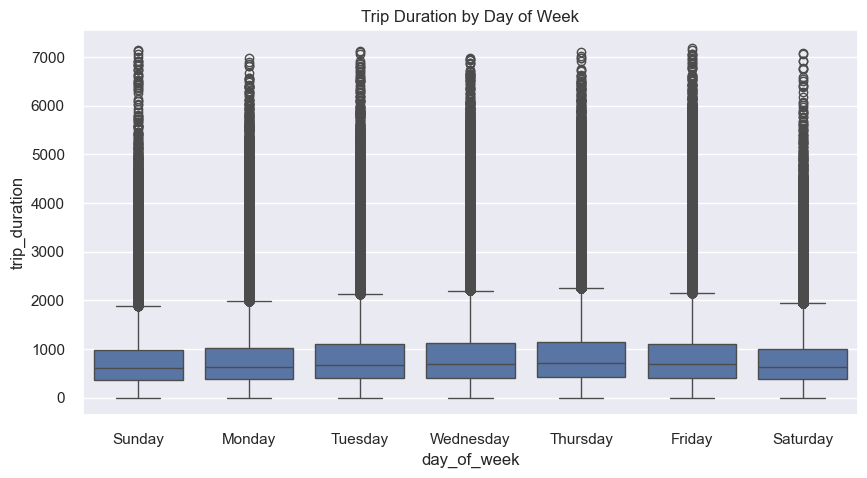

In [5]:
# Checking if certain days have longer trips.
# The differences aren't huge, but it's still good to visualize.

day_order = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='day_of_week', y='trip_duration', order=day_order)
plt.title("Trip Duration by Day of Week")
plt.show()

### Trip Duration by Hour

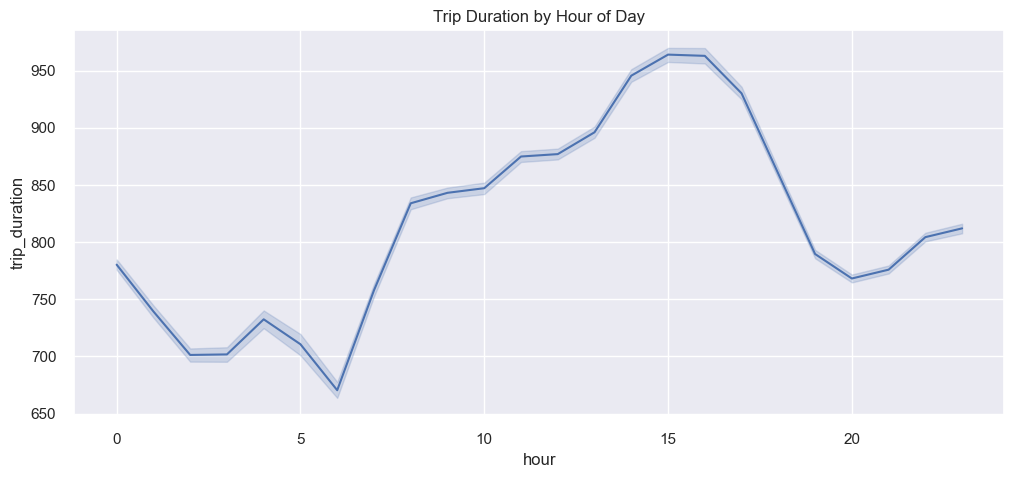

In [6]:
# This shows the rush hour effect pretty clearly.
# Morning and evening bumps match what you'd expect.

plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='hour', y='trip_duration')
plt.title("Trip Duration by Hour of Day")
plt.show()

### Trip Duration vs Distance

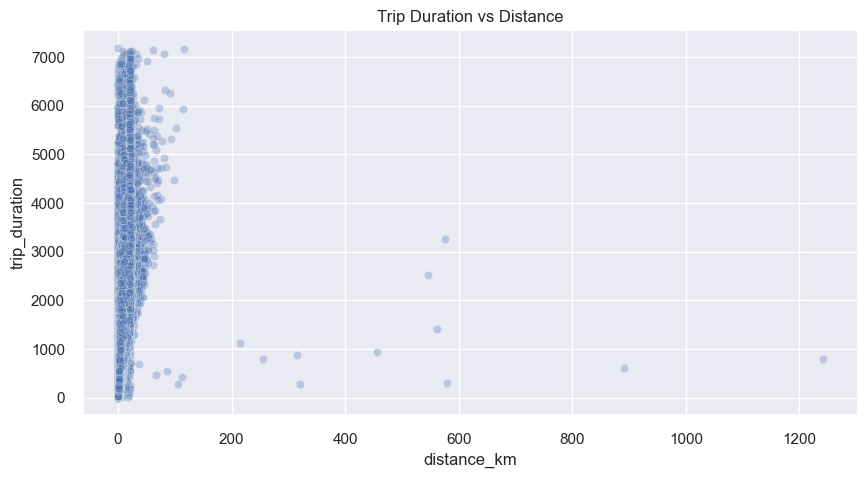

In [7]:
# Distance is obviously a big factor, and this scatterplot confirms it.
# Longer trips take longer, which is expected.

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='distance_km', y='trip_duration', alpha=0.3)
plt.title("Trip Duration vs Distance")
plt.show()

-----------------------------------------
MILESTONE 2 — DATA PREPARATION
-----------------------------------------

## 2.1 Drop Unnecessary Columns

In [8]:
# Dropping columns that don't help the model.
# These either don't add predictive value or I already extracted what I needed.

cols_to_drop = [
    'id','store_and_fwd_flag','vendor_id',
    'pickup_datetime','dropoff_datetime',
    'dropoff_latitude','dropoff_longitude'
]

df = df.drop(columns=cols_to_drop)

## 2.2 Missing Data Check

In [9]:
# Checking for missing values.
# The dataset is pretty clean, so nothing to fix here.

df.isna().sum()

passenger_count     0
pickup_longitude    0
pickup_latitude     0
trip_duration       0
day_of_week         0
hour                0
month               0
distance_km         0
dtype: int64

## 2.3 Additional Feature Engineering

In [10]:
# Adding a weekend flag because weekend traffic can behave differently.
df['is_weekend'] = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)

# Adding a rush hour flag since those times clearly affect trip duration.
df['is_rush_hour'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)

## 2.4 Dummy Variables

In [11]:
# Converting day_of_week into dummy variables.
# Models can't use text categories directly, so this makes them usable.

df = pd.get_dummies(df, columns=['day_of_week'], drop_first=True)

## 2.5 Final Data Check

In [12]:
# Just making sure everything still looks good after all the transformations.
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1456391 entries, 0 to 1458643
Data columns (total 15 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   passenger_count        1456391 non-null  int64  
 1   pickup_longitude       1456391 non-null  float64
 2   pickup_latitude        1456391 non-null  float64
 3   trip_duration          1456391 non-null  int64  
 4   hour                   1456391 non-null  int32  
 5   month                  1456391 non-null  int32  
 6   distance_km            1456391 non-null  float64
 7   is_weekend             1456391 non-null  int64  
 8   is_rush_hour           1456391 non-null  int64  
 9   day_of_week_Monday     1456391 non-null  bool   
 10  day_of_week_Saturday   1456391 non-null  bool   
 11  day_of_week_Sunday     1456391 non-null  bool   
 12  day_of_week_Thursday   1456391 non-null  bool   
 13  day_of_week_Tuesday    1456391 non-null  bool   
 14  day_of_week_Wednesday  

,passenger_count,pickup_longitude,pickup_latitude,trip_duration,hour,month,distance_km,is_weekend,is_rush_hour,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,1,-73.982155,40.767937,455,17,3,1.498521,0,1,True,False,False,False,False,False
1,1,-73.980415,40.738564,663,0,6,1.805507,1,0,False,False,True,False,False,False
2,1,-73.979027,40.763939,2124,11,1,6.385098,0,0,False,False,False,False,True,False
3,1,-74.010040,40.719971,429,19,4,1.485498,0,0,False,False,False,False,False,True
4,1,-73.973053,40.793209,435,13,3,1.188588,1,0,False,True,False,False,False,False


-----------------------------------------
MILESTONE 3 — MODEL BUILDING
-----------------------------------------

## 3.1 Train/Test Split

In [13]:
# Splitting the data into training and testing sets.
# Using 80/20 so the model has plenty to learn from but still gets a fair evaluation.

from sklearn.model_selection import train_test_split

X = df.drop(columns=['trip_duration'])
y = df['trip_duration']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 3.2 Baseline Model

In [14]:
# Creating a simple baseline model that predicts the mean trip duration.
# It's not smart, but it's a good comparison point.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_baseline = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

baseline_mae, baseline_rmse, baseline_r2

(467.4401842062387, np.float64(655.1131605008306), -1.0712950304636593e-08)

## 3.3 Linear Regression

In [15]:
# Fitting a simple Linear Regression model.
# This gives me a baseline for a real model that's still easy to interpret.

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

lr_mae, lr_rmse, lr_r2

(293.79038110063635, np.float64(475.8272523447749), 0.4724471413712983)

## 3.4 Random Forest

In [16]:
# Trying a Random Forest model to capture non-linear relationships.
# I limited the depth and number of trees to avoid memory issues.

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=15,
    max_features='sqrt',
    random_state=42,
    n_jobs=1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

rf_mae, rf_rmse, rf_r2

(224.73753359991838, np.float64(337.5265457133089), 0.7345496964944198)

---------------------------------------------------------
NEW SINCE MILESTONE 3 — FINAL PROJECT ADDITIONS
---------------------------------------------------------

## 4.1 Feature Importance Plot

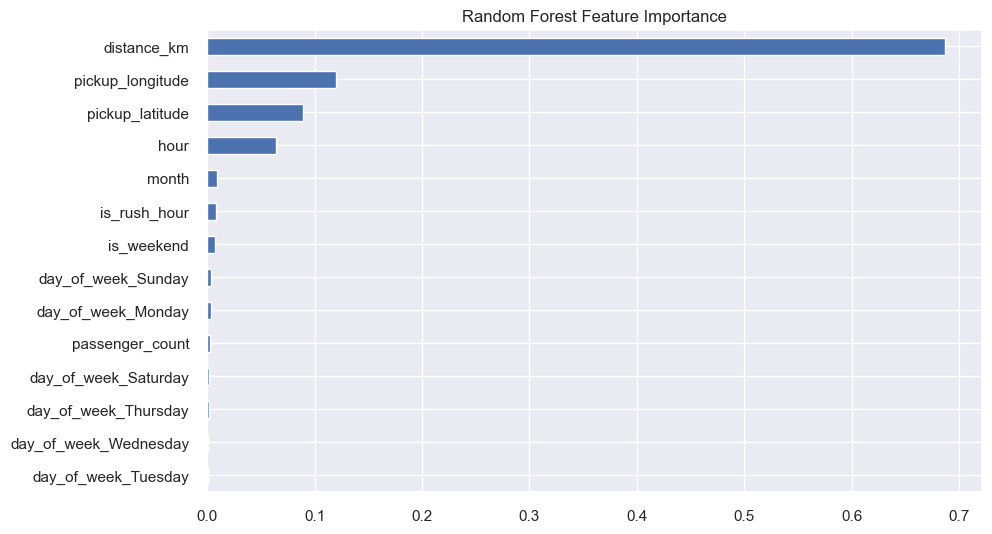

In [17]:
# Plotting feature importance from the Random Forest model.
# This helps me see which features the model relies on the most.

importances = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

## 4.2 Residual Plot

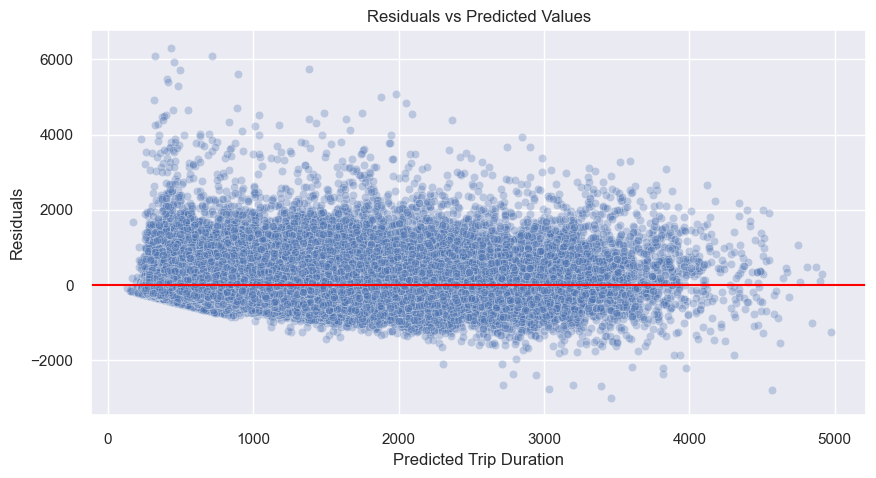

In [18]:
# Plotting residuals to check for patterns.
# Ideally, residuals should be randomly scattered around zero.

residuals = y_test - y_pred_rf

plt.figure(figsize=(10,5))
sns.scatterplot(x=y_pred_rf, y=residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Trip Duration")
plt.ylabel("Residuals")
plt.show()

## 4.3 Error by Distance

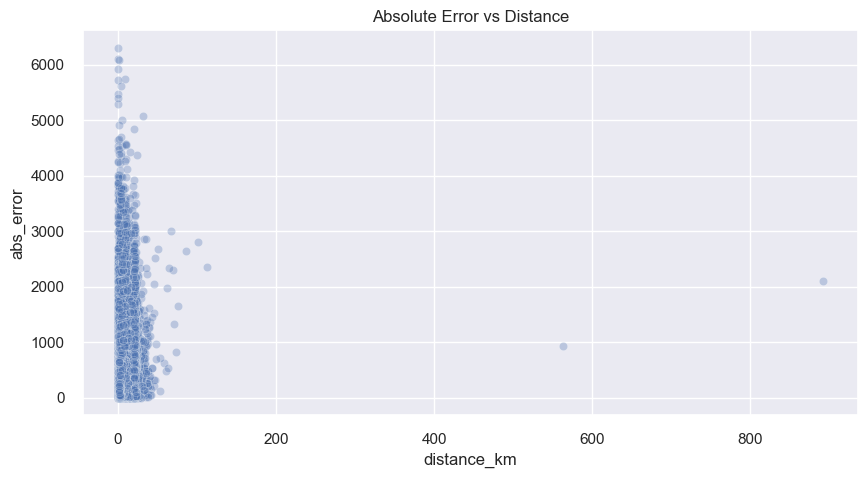

In [19]:
# Checking how error behaves across different distances.
# Short trips tend to have higher relative error because small delays matter more.

df_errors = pd.DataFrame({
    'distance_km': X_test['distance_km'],
    'abs_error': np.abs(residuals)
})

plt.figure(figsize=(10,5))
sns.scatterplot(data=df_errors, x='distance_km', y='abs_error', alpha=0.3)
plt.title("Absolute Error vs Distance")
plt.show()

-----------------------------------------
FINAL INTERPRETATION
-----------------------------------------

## Summary and Recommendations
The Random Forest model performed the best and explained about 73% of the variation in trip duration. Distance was the strongest predictor, followed by hour, month, and rush hour. The residuals looked reasonable, and the model didn’t show major bias. The model is close to being deployable but would benefit from hyperparameter tuning, adding real-time features like weather or traffic, and possibly doing gradient boosting models. The project shows that trip duration can be predicted pretty well using engineered features and tree-based models.